# Metodos Computacionales en Ingenieria
## Taller Integración y Diferenciación
### Elaborado Por: Carlos Alberto Castillo Daza

# Ejercicio 1: Integración de una función

## Planteamiento

Considere la función:

$$
f(x) = e^{-0.4x}\left(1 + 0.5\sin(3x)\right),
\qquad 0 \leq x \leq 8.
$$

Esta función puede interpretarse como una **señal que presenta una tendencia decreciente acompañada de una componente oscilatoria**.



## A. Análisis matemático

1. Determine si puede obtenerse una expresión analítica y, si la obtiene, úsela como referencia;de lo contrario, defina una referencia numérica de alta precisión.
2. Explique qué representa el área acumulada.
3. Identifique características que puedan afectar la aproximación.

In [1]:
#Librerias

import timeit
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.integrate import quad, trapezoid, simpson, cumulative_trapezoid
from scipy.interpolate import CubicSpline

### Función para determinar referencia analitica

In [2]:
def f(x):
    return np.exp(-0.4 * x) * (1 + 0.5 * np.sin(3 * x))


a, b = 0.0, 8.0
al, be, L = 0.4, 3.0, 8.0
I_ref = (1 - np.exp(-al * L)) / al + 0.5 * (
    be - np.exp(-al * L) * (al * np.sin(be * L) + be * np.cos(be * L))
) / (al**2 + be**2)
print(f" EJERCICIO 1 \nReferencia analítica: {I_ref:.15f}\n")


 EJERCICIO 1 
Referencia analítica: 2.559824508302063



### Función Trapecio

In [3]:
def trapecio(fun, a, b, n):
    x = np.linspace(a, b, n + 1)
    return trapezoid(fun(x), x)


     n             Trapecio    Error abs   Tiempo [s]
    10    2.494072510185698    6.575e-02    1.055e-05
    20    2.544929716211617    1.489e-02    1.224e-05
    50    2.557502776878404    2.322e-03    1.258e-05
   100    2.559246207984130    5.783e-04    1.250e-05
   500    2.559801403459291    2.310e-05    2.201e-05
  1000    2.559818732303389    5.776e-06    2.593e-05

  epsrel                 quad  Err. estim.    Err. real  neval   Tiempo [s]
   1e-04    2.559824508302063    1.458e-10    4.441e-16     63    2.470e-05
   1e-06    2.559824508302063    1.458e-10    4.441e-16     63    2.531e-05
   1e-10    2.559824508302063    1.458e-10    4.441e-16     63    2.613e-05
   1e-13    2.559824508302063    2.842e-14    0.000e+00    147    5.952e-05
quad por defecto: I = 2.559824508302063, err_est = 1.46e-10, err_real = 4.44e-16


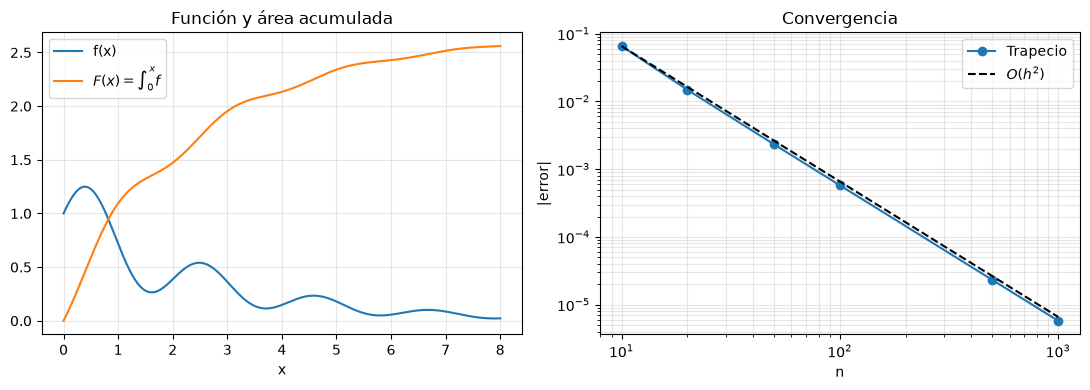

In [4]:
print(f"{'n':>6} {'Trapecio':>20} {'Error abs':>12} {'Tiempo [s]':>12}")
filas = []
for n in [10, 20, 50, 100, 500, 1000]:
    I = trapecio(f, a, b, n)
    t = min(timeit.repeat(lambda: trapecio(f, a, b, n), number=2000, repeat=3)) / 2000
    filas.append((n, I, abs(I - I_ref), t))
    print(f"{n:6d} {I:20.15f} {abs(I - I_ref):12.3e} {t:12.3e}")

print(f"\n{'epsrel':>8} {'quad':>20} {'Err. estim.':>12} {'Err. real':>12} {'neval':>6} {'Tiempo [s]':>12}")
for tol in [1e-4, 1e-6, 1e-10, 1e-13]:
    I, err, info = quad(f, a, b, epsabs=0, epsrel=tol, full_output=True)
    t = min(timeit.repeat(lambda: quad(f, a, b, epsabs=0, epsrel=tol), number=2000, repeat=3)) / 2000
    print(f"{tol:8.0e} {I:20.15f} {err:12.3e} {abs(I - I_ref):12.3e} {info['neval']:6d} {t:12.3e}")

# Valores por defecto de quad: epsabs=1.49e-8, epsrel=1.49e-8, limit=50
I, err = quad(f, a, b)
print(f"quad por defecto: I = {I:.15f}, err_est = {err:.2e}, err_real = {abs(I - I_ref):.2e}")

# Figura de convergencia
filas = np.array(filas)
fig, ax = plt.subplots(1, 2, figsize=(11, 4))
xx = np.linspace(a, b, 1000)
ax[0].plot(xx, f(xx), label="f(x)")
ax[0].plot(xx, cumulative_trapezoid(f(xx), xx, initial=0), label=r"$F(x)=\int_0^x f$")
ax[0].set_xlabel("x"); ax[0].legend(); ax[0].grid(alpha=.3)
ax[0].set_title("Función y área acumulada")
ax[1].loglog(filas[:, 0], filas[:, 2], "o-", label="Trapecio")
ax[1].loglog(filas[:, 0], filas[0, 2] * (filas[0, 0] / filas[:, 0]) ** 2, "k--", label=r"$O(h^2)$")
ax[1].set_xlabel("n"); ax[1].set_ylabel("|error|"); ax[1].legend(); ax[1].grid(alpha=.3, which="both")
ax[1].set_title("Convergencia")
fig.tight_layout(); 


# Ejercicio 2: Integración de 50 datos equiespaciados

## Planteamiento

Considere un conjunto de **50 mediciones equiespaciadas** definidas por:

$$
x_i = 0.2i,
\qquad i=0,\ldots,49
$$

A cada valor $x_i$ le corresponde una medición $y_i$ generada mediante:

$$
y_i =
2.0
+0.35\sin(0.7x_i)
+0.15\cos(2.1x_i)
+0.03x_i
$$

La expresión anterior se utilizará **únicamente para generar los datos sintéticos** que serán entregados al estudiante.



In [5]:
# Mediciones equiespaciadas: x_i = 0.2 i, i = 0,...,49
i = np.arange(50)
x = 0.2 * i
y = 2.0 + 0.35*np.sin(0.7*x) + 0.15*np.cos(2.1*x) + 0.03*x

datos = pd.DataFrame({"x": x, "y": y})
datos.head()

,x,y
0,0.0,2.150000
1,0.2,2.191803
2,0.4,2.208844
3,0.6,2.206589
4,0.8,2.193567


In [6]:
ruta = Path("datos_sensor.csv")
datos.to_csv(ruta, index=False, float_format="%.10f")
print(f"Archivo guardado en: {ruta.resolve()}")

Archivo guardado en: /home/carlos/MCEI_2620/Python/jupyter_lab/datos_sensor.csv


Carga de Archivo generado datos_sensor

In [7]:
data = pd.read_csv("datos_sensor.csv")
print("Columnas:", list(data.columns))
data.head()

Columnas: ['x', 'y']


,x,y
0,0.0,2.150000
1,0.2,2.191803
2,0.4,2.208844
3,0.6,2.206589
4,0.8,2.193567


Calculo de: 
$$
I = \int_{0}^{9.8} y(x)\, dx
$$

In [8]:
x, y = data["x"].values, data["y"].values
h = np.diff(x)
assert np.allclose(h, h[0], atol=1e-9)
h = h[0]


I_trap = trapezoid(y, x)
I_simp = simpson(y, x=x)  
I_simp_manual = simpson(y[:47], x=x[:47]) + 3 * h / 8 * (y[46] + 3 * y[47] + 3 * y[48] + y[49])

I_spline = CubicSpline(x, y, bc_type="natural").integrate(x[0], x[-1])

print(f"trapezoid                    : {I_trap:.10f}")
print(f"simpson (SciPy)              : {I_simp:.10f}")
print(f"Simpson 1/3 (46) + 3/8 (3)   : {I_simp_manual:.10f}")
print(f"Cubic Spline natural          : {I_spline:.10f}")
print(f"Diferencia trapecio-Simpson  : {I_trap - I_simp:.3e} ({100*abs(I_trap-I_simp)/I_simp:.4f} %)")


trapezoid                    : 21.1908463399
simpson (SciPy)              : 21.1921130983
Simpson 1/3 (46) + 3/8 (3)   : 21.1920398006
Cubic Spline natural          : 21.1918882576
Diferencia trapecio-Simpson  : -1.267e-03 (0.0060 %)


###  EXTENSIÓN: derivadas 


=== EXTENSIÓN ===
Error máx. adelante : 8.072e-02
Error máx. centrada : 1.665e-02
  sigma  ΔIntegral rel  Err. deriv. rel
  0.001       5.27e-05         1.55e-02
  0.005       2.56e-04         7.74e-02
  0.010       5.06e-04         1.57e-01
  0.050       2.62e-03         7.79e-01


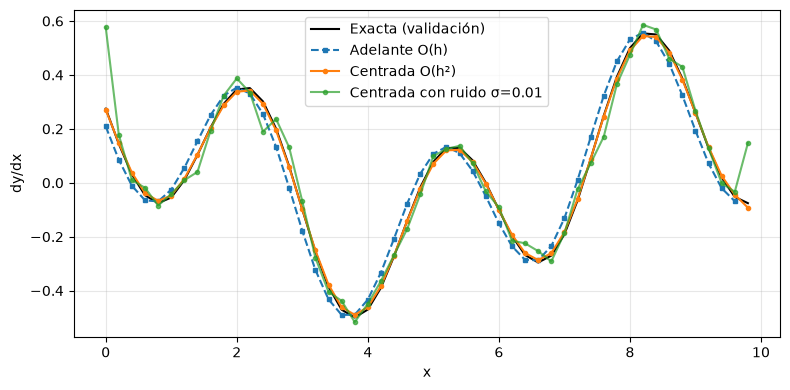

In [10]:
d_fwd = np.append(np.diff(y) / h, np.nan)
d_cen = np.gradient(y, h, edge_order=2)  # centrada interior + unilaterales O(h^2)
d_ex = 0.35 * 0.7 * np.cos(0.7 * x) - 0.15 * 2.1 * np.sin(2.1 * x) + 0.03  # solo para validar
print("\n=== EXTENSIÓN ===")
print(f"Error máx. adelante : {np.nanmax(np.abs(d_fwd - d_ex)):.3e}")
print(f"Error máx. centrada : {np.max(np.abs(d_cen - d_ex)):.3e}")

rng = np.random.default_rng(1)
print(f"{'sigma':>7} {'ΔIntegral rel':>14} {'Err. deriv. rel':>16}")
for sig in [0.001, 0.005, 0.01, 0.05]:
    dI, dD = [], []
    for _ in range(500):
        yn = y + sig * rng.standard_normal(y.size)
        dI.append(abs(trapezoid(yn, x) - I_trap) / abs(I_trap))
        dD.append(np.sqrt(np.mean((np.gradient(yn, h, edge_order=2) - d_cen) ** 2)) / np.std(d_ex))
    print(f"{sig:7.3f} {np.mean(dI):14.2e} {np.mean(dD):16.2e}")

yn = y + 0.01 * rng.standard_normal(y.size)
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(x, d_ex, "k-", label="Exacta (validación)")
ax.plot(x, d_fwd, "s--", ms=3, label="Adelante O(h)")
ax.plot(x, d_cen, "o-", ms=3, label="Centrada O(h²)")
ax.plot(x, np.gradient(yn, h, edge_order=2), ".-", alpha=.7, label="Centrada con ruido σ=0.01")
ax.set_xlabel("x"); ax.set_ylabel("dy/dx"); ax.legend(); ax.grid(alpha=.3)
fig.tight_layout();
